In [1]:
import torch
from torch import nn
import pandas as pd
import sys
from pathlib import Path

train_labels = pd.read_csv('../cifar-10/trainLabels.csv')
val_labels = pd.read_csv('../cifar-10/valLabels.csv')

sys.path.append(str(Path.cwd().parent))
torch.manual_seed(42)

In [2]:
from src.dataset import CIFAR10Dataset, train_transforms, val_transforms

train_dataset = CIFAR10Dataset(
    image_dir='../cifar-10/train',
    labels=train_labels,
    transform=train_transforms
)

val_dataset = CIFAR10Dataset(
    image_dir='../cifar-10/val',
    labels=val_labels,
    transform=val_transforms
)

In [3]:
from src.dataset import create_dataloader

train_loader = create_dataloader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = create_dataloader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False
)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [5]:
from src.models import CIFARBatchNorm
from src.metrics import create_metrics
from src.engine import fit

model = CIFARBatchNorm().to(device)

train_metrics = create_metrics(num_classes=10)
val_metrics = create_metrics(num_classes=10)

for metric in train_metrics.values():
    metric = metric.to(device)
for metric in val_metrics.values():
    metric = metric.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
epochs = 30

history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_metrics=train_metrics,
    val_metrics=val_metrics,
    epochs=epochs,
    device=device,
    file_path='../models/CIFAR_Augmentation_WD_BatchNorm.pt'
)

history


Epoch 1/30:
Training Loss: 1.4910 | Training Accuracy: 45.27% | Training Precision: 44.56% | Training Recall: 45.27%
Validation Loss: 1.1864 | Validation Accuracy: 56.92% | Validation Precision: 60.11% | Validation Recall: 56.92%
Best model saved! Val Acc: 56.92%

Epoch 2/30:
Training Loss: 1.1134 | Training Accuracy: 60.11% | Training Precision: 59.67% | Training Recall: 60.11%
Validation Loss: 1.0595 | Validation Accuracy: 63.16% | Validation Precision: 68.11% | Validation Recall: 63.16%
Best model saved! Val Acc: 63.16%

Epoch 3/30:
Training Loss: 0.9728 | Training Accuracy: 65.33% | Training Precision: 65.00% | Training Recall: 65.33%
Validation Loss: 0.8670 | Validation Accuracy: 68.92% | Validation Precision: 70.59% | Validation Recall: 68.92%
Best model saved! Val Acc: 68.92%

Epoch 4/30:
Training Loss: 0.8941 | Training Accuracy: 68.54% | Training Precision: 68.34% | Training Recall: 68.54%
Validation Loss: 0.9661 | Validation Accuracy: 66.34% | Validation Precision: 71.60% | 

,epoch,train_loss,train_accuracy,train_precision,train_recall,val_loss,val_accuracy,val_precision,val_recall
0,1,1.491022,0.452675,0.445607,0.452675,1.186354,0.5692,0.601062,0.5692
1,2,1.113364,0.601050,0.596693,0.601050,1.059523,0.6316,0.681147,0.6316
2,3,0.972810,0.653300,0.650036,0.653300,0.866962,0.6892,0.705936,0.6892
3,4,0.894095,0.685375,0.683393,0.685375,0.966053,0.6634,0.716029,0.6634
4,5,0.834343,0.704525,0.702615,0.704525,0.735937,0.7362,0.744973,0.7362
5,6,0.786884,0.722325,0.720690,0.722325,0.858987,0.7020,0.750766,0.7020
6,7,0.740162,0.741375,0.740118,0.741375,0.711255,0.7538,0.769728,0.7538
7,8,0.706105,0.753200,0.751956,0.753200,0.671558,0.7598,0.776533,0.7598
8,9,0.671767,0.765775,0.764824,0.765775,0.641630,0.7782,0.781259,0.7782
9,10,0.644806,0.773575,0.772687,0.773575,0.626420,0.7832,0.795477,0.7832


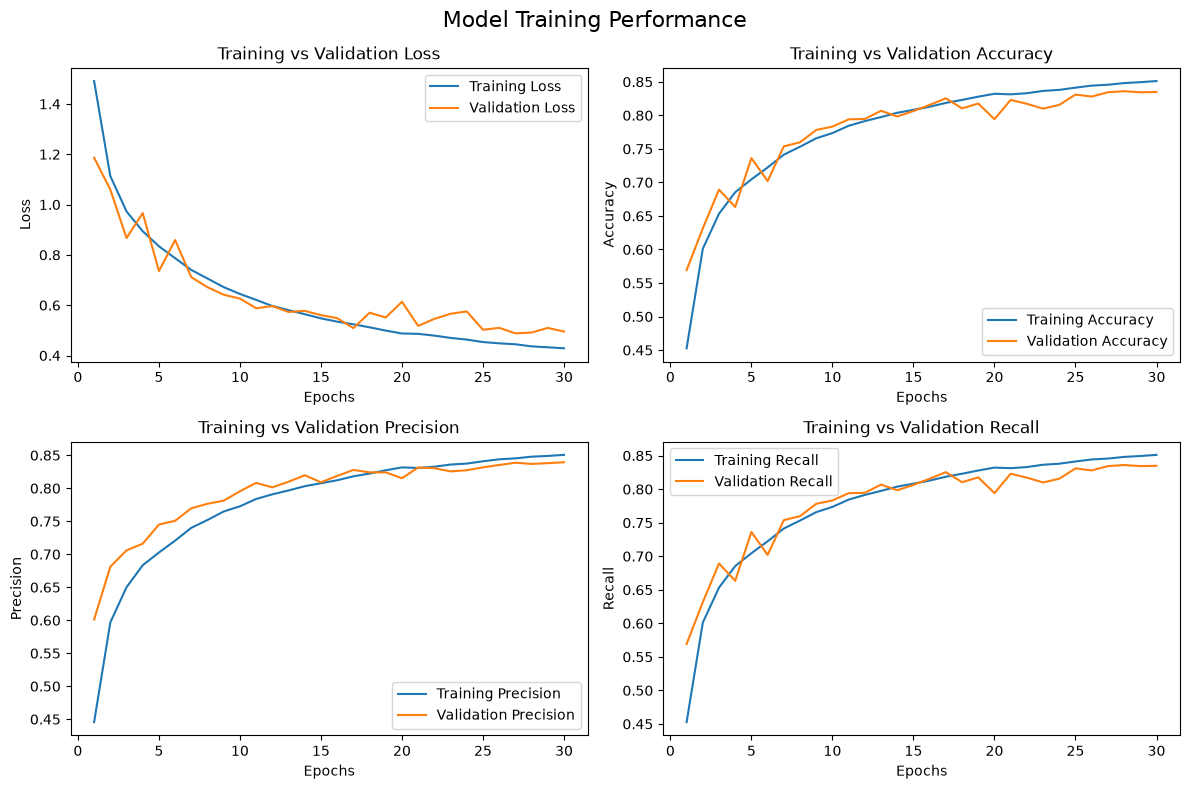

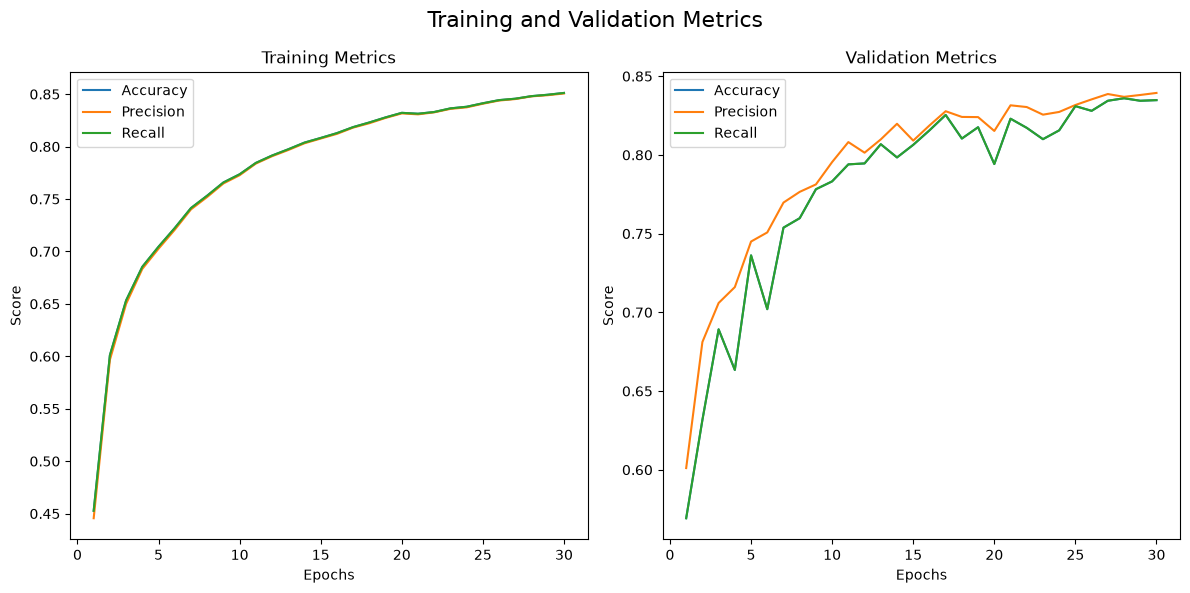

In [6]:
from src.plots import plot_all_metrics, plot_performance

plot_all_metrics(history=history)
plot_performance(history=history)